# Análise de Comorbidades Críticass

**Hipertensão, colesterol alto e sua associação com diabetes**.

Esta análise explora a relação entre comorbidades crônicas autorrelatadas — hipertensão e colesterol alto — e a presença de diabetes, em uma base de mais de 250 mil respostas do Behavioral Risk Factor Surveillance System (BRFSS) de 2015. O objetivo é quantificar o quanto a prevalência de diabetes varia entre pessoas que relatam essas condições e aquelas que não relatam, e usar essa informação para embasar a estratificação de risco no aplicativo.

**Dataset: CDC Diabetes Health Indicators (BRFSS 2015)**

## 1. Setup e Criação das Variáveis de Análise

- Carregamos o dataset e selecionamos as variáveis que serão a base do Eixo 1:

- **Diabetes_binary:** indica se a pessoa tem pré-diabetes ou diabetes (1) ou não (0);

- **HighBP:** indica se a pessoa relata pressão alta (1) ou não (0);

- **HighChol:** indica se a pessoa relata colesterol alto (1) ou não (0).

A partir delas, vamos calcular:

- prevalência de diabetes entre expostos e não expostos a cada comorbidade;

- razão de prevalências (PR) e odds ratio (OR) com intervalos de confiança de 95%;

- p-valor do teste exato de Fisher;

- perfis combinados (ex.: “apenas hipertensão”, “hipertensão + colesterol alto”).


In [11]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

variaveis_eixo1 = ["Diabetes_binary", "HighBP", "HighChol"]
variaveis_ausentes = [v for v in variaveis_eixo1 if v not in df.columns]

if variaveis_ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {variaveis_ausentes}")

pd.DataFrame({
    "Indicador": ["Linhas", "Colunas"],
    "Valor": [df.shape[0], df.shape[1]]
})

,Indicador,Valor
0,Linhas,253680
1,Colunas,22


> **Observação:** As variáveis HighBP e HighChol representam pressão alta e colesterol alto autorrelatados, e não medidas clínicas diretas.

## 2. Função para medir associação

Para cada relação binária serão calculados:

- prevalência do diabetes nos grupos exposto e não exposto;
- **PR (Razão de Prevalências)** com IC95%;
- **OR (Odds Ratio)** com IC95%;
- **p-valor de Fisher**, como evidência complementar de associação.

A estrutura da função foi utilizada porque permite reutilizar a mesma lógica nas análises de `HighBP` e `HighChol`.


In [3]:
def calcular_associacao(df, exposure_col, outcome_col, nome_exposicao, nome_desfecho):
    dados = df[[exposure_col, outcome_col]].dropna().copy()

    ct = pd.crosstab(dados[exposure_col], dados[outcome_col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )

    a = int(ct.loc[1, 1])
    b = int(ct.loc[1, 0])
    c = int(ct.loc[0, 1])
    d = int(ct.loc[0, 0])

    n_expostos = a + b
    n_nao_expostos = c + d

    if n_expostos == 0 or n_nao_expostos == 0:
        return {
            "Exposição": nome_exposicao,
            "Desfecho": nome_desfecho,
            "Prevalência expostos (%)": np.nan,
            "Prevalência não expostos (%)": np.nan,
            "PR": np.nan,
            "PR IC95%": "NA",
            "OR": np.nan,
            "OR IC95%": "NA",
            "p-valor": np.nan
        }

    p_expostos = a / n_expostos
    p_nao_expostos = c / n_nao_expostos

    # Razão de prevalências
    if p_nao_expostos == 0:
        pr = np.nan
        pr_ic = (np.nan, np.nan)
    else:
        pr = p_expostos / p_nao_expostos
        if a == 0 or c == 0:
            se_log_pr = np.nan
            pr_ic = (np.nan, np.nan)
        else:
            se_log_pr = np.sqrt(
                (1 / a) - (1 / n_expostos) +
                (1 / c) - (1 / n_nao_expostos)
            )
            pr_ic = (
                np.exp(np.log(pr) - 1.96 * se_log_pr),
                np.exp(np.log(pr) + 1.96 * se_log_pr)
            )

    # Odds Ratio
    if min(a, b, c, d) == 0:
        or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
        or_ic = (np.nan, np.nan)
    else:
        or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        or_ic = (
            np.exp(np.log(or_value) - 1.96 * se_log_or),
            np.exp(np.log(or_value) + 1.96 * se_log_or)
        )

    return {
        "Exposição": nome_exposicao,
        "Desfecho": nome_desfecho,
        "Prevalência expostos (%)": p_expostos * 100,
        "Prevalência não expostos (%)": p_nao_expostos * 100,
        "PR": pr,
        "PR IC95%": f"[{pr_ic[0]:.2f} – {pr_ic[1]:.2f}]" if np.isfinite(pr) else "NA",
        "OR": or_value,
        "OR IC95%": f"[{or_ic[0]:.2f} – {or_ic[1]:.2f}]" if np.isfinite(or_value) else "NA",
        "p-valor": p_value
    }

## 3. Tabelas 2×2: diabetes por hipertensão e colesterol

O primeiro passo é entender como a presença de diabetes se distribui entre quem relata ou não hipertensão e colesterol alto. Para isso, construímos tabelas de contingência 2×2, mostrando contagem e porcentagem dentro de cada grupo.


In [4]:
def tabela_2x2_linha(df, exposure_col, exposure_label):
    dados = df[[exposure_col, "Diabetes_binary"]].dropna().copy()

    ct = pd.crosstab(dados[exposure_col], dados["Diabetes_binary"]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100)

    tabela = ct.astype(int).astype(str) + " (" + pct.round(2).astype(str) + "%)"
    tabela.columns = ["Sem diabetes", "Com diabetes"]
    tabela.index = [f"{exposure_label} = 0 (ausente)", f"{exposure_label} = 1 (presente)"]
    return tabela

tabela_highbp = tabela_2x2_linha(df, "HighBP", "HighBP")
tabela_highchol = tabela_2x2_linha(df, "HighChol", "HighChol")

tabela_highbp


,Diabetes = 0,Diabetes = 1
HighBP = 0,136109 (93.96%),8742 (6.04%)
HighBP = 1,82225 (75.55%),26604 (24.45%)


**Leitura da tabela de hipertensão:**

> Na linha Hipertensão = 0, vemos quantas pessoas sem pressão alta relatam ou não diabetes, e a porcentagem de diabetes dentro desse grupo.

> Na linha Hipertensão = 1, fazemos o mesmo para quem relata pressão alta.

Um padrão esperado é que a porcentagem de diabetes seja maior na linha Hipertensão = 1, indicando uma associação positiva entre as duas condições.

In [5]:
tabela_highchol


,Diabetes = 0,Diabetes = 1
HighChol = 0,134429 (92.02%),11660 (7.98%)
HighChol = 1,83905 (77.99%),23686 (22.01%)


## 4. Prevalência de diabetes segundo comorbidades


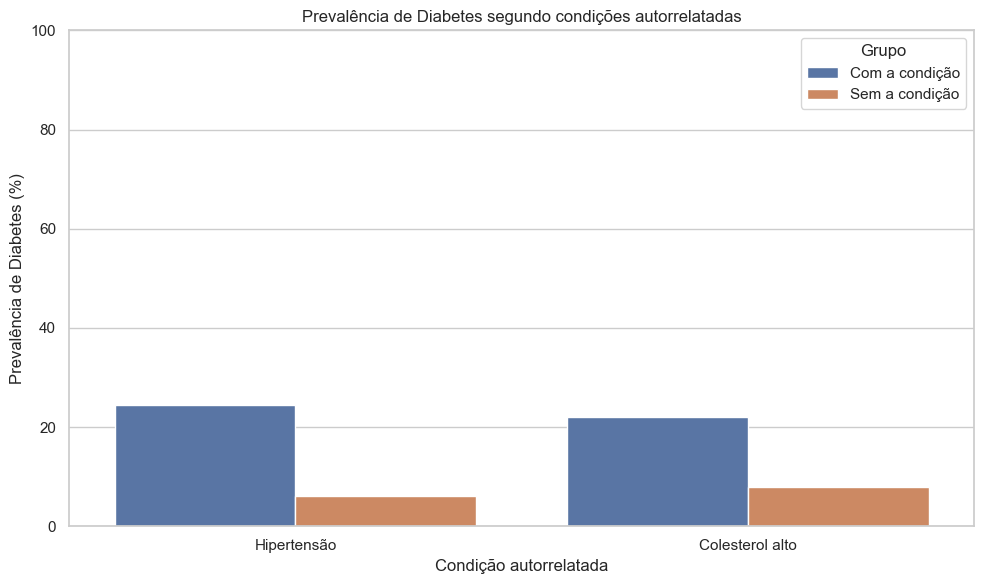

In [6]:
analises = [
    ("Hipertensão", "Diabetes", "HighBP", "Diabetes_binary"),
    ("Colesterol alto", "Diabetes", "HighChol", "Diabetes_binary")
]

resultados = [
    calcular_associacao(df, exposure_col, outcome_col, nome_exposicao, nome_desfecho)
    for nome_exposicao, nome_desfecho, exposure_col, outcome_col in analises
]

tabela_associacoes = pd.DataFrame(resultados)

grafico_diabetes = tabela_associacoes.melt(
    id_vars="Exposição",
    value_vars=["Prevalência expostos (%)", "Prevalência não expostos (%)"],
    var_name="Grupo",
    value_name="Prevalência (%)"
)

grafico_diabetes["Grupo"] = grafico_diabetes["Grupo"].replace({
    "Prevalência expostos (%)": "Com a condição",
    "Prevalência não expostos (%)": "Sem a condição"
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=grafico_diabetes,
    x="Exposição",
    y="Prevalência (%)",
    hue="Grupo"
)
plt.title("Prevalência de diabetes segundo hipertensão e colesterol alto autorrelatados")
plt.xlabel("Condição autorrelatada")
plt.ylabel("Prevalência de Diabetes (%)")
plt.ylim(0, 100)
plt.legend(title="Grupo", loc="upper left")
plt.tight_layout()
plt.show()


O gráfico acima revela o nível de vulnerabilidade clínica de cada grupo.  
Note que a diferença entre as barras “Com a condição” e “Sem a condição” funciona como um alerta: categorias em que a prevalência de diabetes é muito maior entre quem relata hipertensão ou colesterol alto concentram indivíduos com maior carga de doença e, potencialmente, maior risco cardiovascular.

Interessante notar que mesmo condições muito comuns, como pressão alta e colesterol alto, já identificam subgrupos com prevalência de diabetes claramente elevada. Isso sugere que o acúmulo de fatores de risco (hipertensão, dislipidemia e outros) acompanha o aumento da prevalência de diabetes, reforçando a importância de um acompanhamento integrado dessas condições no aplicativo.

## 5. Associação entre hipertensão, colesterol alto e diabetes

A tabela reúne as principais medidas de associação

>Razão de Prevalências (PR - Prevalence Ratio): É a nossa métrica principal nesta análise transversal. Ela indica, de forma direta e intuitiva, quantas vezes o diabetes é mais comum no grupo que possui a comorbidade (ex: hipertensão) em comparação com o grupo que não a possui.

>Razão de Chance (OR - Odds Ratio): Apresentada como uma medida estatística complementar de probabilidade.

>p-valor: Confirma a significância do resultado (valores próximos a zero indicam que a forte associação encontrada não é obra do acaso).


In [7]:
tabela_exibicao = tabela_associacoes.copy()

cols_pct = ["Prevalência expostos (%)", "Prevalência não expostos (%)"]
for c in cols_pct:
    tabela_exibicao[c] = tabela_exibicao[c].apply(
        lambda x: f"{x:.2f}" if np.isfinite(x) else "NA"
    )

cols_ratio = ["PR", "OR"]
for c in cols_ratio:
    tabela_exibicao[c] = tabela_exibicao[c].apply(
        lambda x: f"{x:.2f}" if np.isfinite(x) else "NA"
    )

tabela_exibicao["p-valor"] = tabela_exibicao["p-valor"].apply(
    lambda x: f"{x:.3e}" if np.isfinite(x) else "NA"
)

tabela_exibicao[[
    "Exposição", "Desfecho", "Prevalência expostos (%)",
    "Prevalência não expostos (%)", "PR", "PR IC95%",
    "OR", "OR IC95%", "p-valor"
]]


,Exposição,Desfecho,Prevalência expostos (%),Prevalência não expostos (%),PR,PR IC95%,OR,OR IC95%,p-valor
0,Hipertensão,Diabetes,24.45,6.04,4.05,[3.96 – 4.14],5.04,[4.91 – 5.17],0.000e+00
1,Colesterol alto,Diabetes,22.01,7.98,2.76,[2.70 – 2.82],3.25,[3.18 – 3.33],0.000e+00


## 6. Perfil combinado: `HighBP` × `HighChol`

Além de analisar cada comorbidade separadamente, criamos um perfil combinado que cruza hipertensão e colesterol alto.
Isso permite ver como a coexistência das duas condições está associada à prevalência de diabetes.


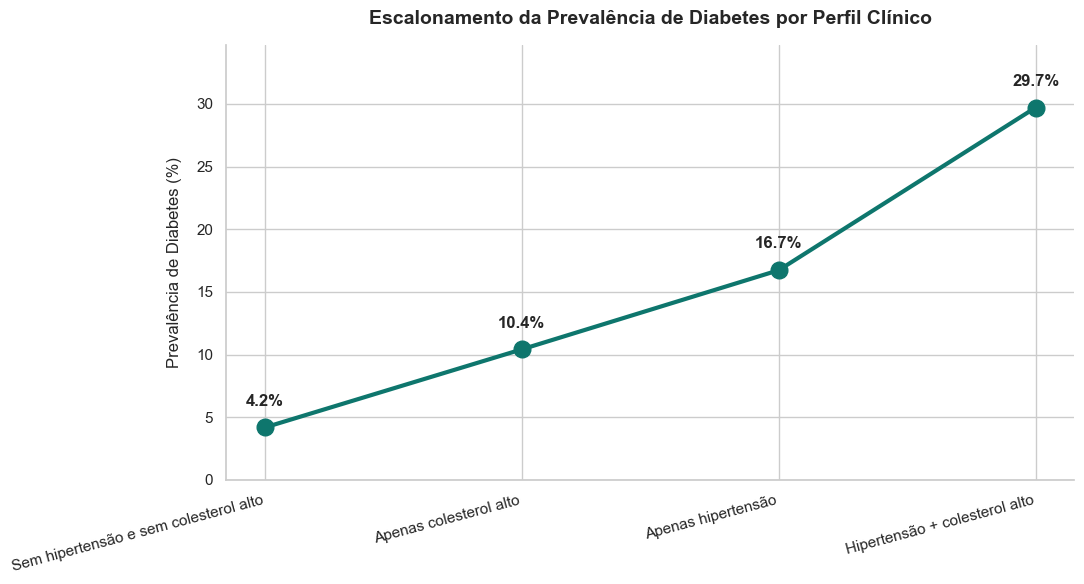

In [10]:
# --- PREPARAÇÃO DOS DADOS (Mantida exatamente igual) ---
condicoes = [
    (df["HighBP"] == 0) & (df["HighChol"] == 0),
    (df["HighBP"] == 0) & (df["HighChol"] == 1),
    (df["HighBP"] == 1) & (df["HighChol"] == 0),
    (df["HighBP"] == 1) & (df["HighChol"] == 1)
]

rotulos = [
    "Sem hipertensão e sem colesterol alto",
    "Apenas colesterol alto",
    "Apenas hipertensão",
    "Hipertensão + colesterol alto"
]

df["Perfil_HighBP_HighChol"] = np.select(
    condicoes,
    rotulos,
    default="Não classificado"
)

dados_perfil = df[df["Perfil_HighBP_HighChol"] != "Não classificado"].copy()

tabela_perfil = pd.crosstab(
    dados_perfil["Perfil_HighBP_HighChol"],
    dados_perfil["Diabetes_binary"],
    normalize="index"
).mul(100).reindex(rotulos).fillna(0)

tabela_perfil.columns = ["Sem Diabetes", "Com Diabetes"]


# --- NOVA VISUALIZAÇÃO: POINT PLOT ---
plt.figure(figsize=(11, 6))

# Criando a linha de tendência com os marcadores
plt.plot(tabela_perfil.index, tabela_perfil["Com Diabetes"], 
         marker='o', markersize=12, linestyle='-', linewidth=3, color='#0E766D') # Usando o verde petróleo do seu app

# Adicionando os rótulos de dados numéricos acima de cada ponto
for i, val in enumerate(tabela_perfil["Com Diabetes"]):
    plt.text(i, val + 1.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Estilização
plt.title("Escalonamento da Prevalência de Diabetes por Perfil Clínico", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Prevalência de Diabetes (%)", fontsize=12, labelpad=10)
plt.xlabel("") # Ocultando o título do eixo X pois os rótulos já são claros
plt.ylim(0, tabela_perfil["Com Diabetes"].max() + 5) # Margem dinâmica
plt.xticks(rotation=15, ha="right", fontsize=11)

sns.despine() # Remove as bordas superior e direita
plt.tight_layout()
plt.show()


O gráfico acima revela o nível de vulnerabilidade clínica de cada perfil de risco cardiovascular.
Note que a fatia vermelha (“Com diabetes”) funciona como um alerta: perfis em que essa parcela é muito grande concentram indivíduos com maior carga de doença e maior probabilidade de já terem diabetes ou pré-diabetes.

É possível observar uma “escada” de risco: quem não tem nenhuma das duas condições apresenta a menor prevalência de diabetes; à medida que se adiciona hipertensão ou colesterol alto, a fatia vermelha aumenta; e o topo dessa escada é o grupo com hipertensão + colesterol alto, que concentra a maior prevalência de diabetes.

Isso mostra que o acúmulo de fatores de risco cardiovascular não é neutro: cada nova condição (pressão alta, dislipidemia) empurra o perfil para uma zona de maior vulnerabilidade clínica. Para o aplicativo, esse é um sinal claro de que usuários com múltiplas comorbidades devem ser prioridade em ações de rastreamento, educação em saúde e acompanhamento mais próximo.

# 7. Conclusões 

A análise das comorbidades revelou que o acúmulo de condições clínicas crônicas é um forte determinante para o aumento na prevalência de diabetes observada na amostra.

>1. **O Efeito Cumulativo:** A presença conjunta de fatores de risco funciona como o principal impulsionador do desfecho clínico. A prevalência de diabetes salta expressivamente de aproximadamente 4% (em pacientes saudáveis) para quase 30% quando hipertensão e colesterol alto coexistem. Isso comprova que a carga de múltiplas doenças crônicas define os grupos de maior vulnerabilidade.

>2. **A Via de Mão Dupla:** Comorbidades como colesterol elevado e histórico de doenças cardiovasculares atuam como fortes associadores bidirecionais. A identificação de uma dessas condições eleva de forma estatisticamente significativa as Razões de Prevalência (PR) para a outra, revelando uma interdependência clínica severa (diabetes e hipertensão se retroalimentam).

>3. **A Importância do Rastreamento Integrado:** A análise confirma que o mapeamento isolado de uma única métrica subestima o risco real do paciente. Estratégias eficazes de triagem e saúde preventiva devem focar obrigatoriamente no perfil clínico combinado e na presença simultânea das comorbidades para permitir a identificação precoce e intervenções adequadas.
